In [33]:
# ═══ CORE ═══════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd

# ═══ VISUALIZATION ════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mtick
from matplotlib.patches import Patch
import seaborn as sns

# ═══ STATS ════════════════════════════════════════════════════════════════════
from scipy import stats
from scipy.stats import (
    skew, kurtosis, describe,
    shapiro, normaltest, anderson, kstest,
    pearsonr, spearmanr, kendalltau, pointbiserialr,
    chi2_contingency, fisher_exact,
    ttest_ind, mannwhitneyu, f_oneway, kruskal,
    ks_2samp, levene, bartlett,
    boxcox, yeojohnson, zscore, iqr
)
from scipy.cluster import hierarchy as sch

# ═══ SKLEARN (pre-model only) ════════════════════════════════════════════════
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer

# ═══ DISPLAY CONFIG ═══════════════════════════════════════════════════════════
import warnings; warnings.filterwarnings('ignore')
from IPython.display import display, HTML

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', 60)

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# ═══ PLOT THEME ═══════════════════════════════════════════════════════════════
PALETTE   = sns.color_palette("tab10")
DIV_PAL   = "coolwarm"
SEQ_PAL   = "Blues"
BG        = "#F8F8F8"

sns.set_theme(style="whitegrid", palette="tab10",
              rc={"figure.facecolor": BG, "axes.facecolor": BG,
                  "axes.spines.top": False, "axes.spines.right": False,
                  "grid.color": "#E0E0E0", "grid.linewidth": 0.6})
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                      "axes.titlesize": 12, "axes.titleweight": "bold"})

# ═══ PROJECT CONSTANTS ════════════════════════════════════════════════════════
TARGET      = "SalePrice"         # ← your target column
TASK_TYPE   = "regression" # ← "classification" | "regression"
ID_COL      = ["PID", "Order"]            # ← ID column or None
RANDOM_SEED = 42
N_SAMPLE    = 5_000            # sample size for heavy plots on large datasets

print("✓ Setup complete")


✓ Setup complete


In [45]:
# ═══ MASTER HELPER FUNCTIONS (do not edit mid-project) ═══════════════════════

# ─── Audit helpers ────────────────────────────────────────────────────────────
def df_audit(df):
    """Full schema audit: dtype, null %, unique count, sample, memory."""
    d = pd.DataFrame({
        "dtype":    df.dtypes,
        "n_null":   df.isnull().sum(),
        "pct_null": (df.isnull().mean() * 100).round(2),
        "n_unique": df.nunique(),
        "pct_unique": (df.nunique() / len(df) * 100).round(2),
        "sample_val": [df[c].dropna().iloc[0] if df[c].notna().any() else None
                       for c in df.columns],
        "mem_kb":   (df.memory_usage(deep=True) / 1024).round(2).values[1:]
    })
    d.index.name = "feature"
    return d.sort_values("pct_null", ascending=False)

def null_heatmap(df, figsize=None):

    if figsize is None:
        figsize = (max(18, len(df.columns) * 0.3), 8)

    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        df.isnull(),
        cmap="viridis",
        yticklabels=False,
        cbar=False,
        ax=ax
    )

    plt.xticks(rotation=90, fontsize=8)

    ax.set_title("Missing Value Map (Yellow = Missing)")

    plt.tight_layout()
    plt.show()

def null_bar(df, figsize=None):

    null_pct = df.isnull().mean().sort_values(ascending=False)
    null_pct = null_pct[null_pct > 0]

    if null_pct.empty:
        print("No missing values.")
        return

    if figsize is None:
        figsize = (12, max(6, len(null_pct) * 0.35))

    fig, ax = plt.subplots(figsize=figsize)

    colors = [
        "#e53935" if v > 0.4 else
        "#fb8c00" if v > 0.1 else
        "#1e88e5"
        for v in null_pct
    ]

    ax.barh(
        null_pct.index[::-1],
        null_pct.values[::-1] * 100,
        color=colors[::-1]
    )

    ax.axvline(40, color="red", ls="--", alpha=0.7)
    ax.axvline(10, color="orange", ls="--", alpha=0.7)

    ax.set_xlabel("Missing %")
    ax.set_title("Missing Values per Feature")

    plt.tight_layout()
    plt.show()

# ─── Distribution helpers ──────────────────────────────────────────────────────
def dist_box_qq(series, title=None):
    """3-panel: histogram+KDE / boxplot / Q-Q plot. For any numeric series."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    s = series.dropna()
    title = title or series.name
    # hist + KDE
    sns.histplot(s, kde=True, ax=axes[0], color=PALETTE[0], edgecolor="white")
    axes[0].axvline(s.mean(),   color="red",    linestyle="--", label=f"mean={s.mean():.2f}")
    axes[0].axvline(s.median(), color="green",  linestyle="--", label=f"med={s.median():.2f}")
    axes[0].legend(fontsize=8); axes[0].set_title(f"Distribution: {title}")
    # boxplot
    axes[1].boxplot(s, vert=True, patch_artist=True,
                    boxprops=dict(facecolor=PALETTE[1], alpha=0.6),
                    medianprops=dict(color="black", linewidth=2))
    axes[1].set_title(f"Boxplot: {title}")
    # Q-Q
    stats.probplot(s, dist="norm", plot=axes[2])
    axes[2].set_title(f"Q-Q plot: {title}")
    plt.suptitle(f"Skew={skew(s):.3f}  Kurt={kurtosis(s):.3f}  n={len(s)}", y=1.02)
    plt.tight_layout(); plt.show()

# ─── Bivariate helpers ─────────────────────────────────────────────────────────
def num_vs_target(df, col, target=TARGET, task=TASK_TYPE):
    """3-panel numeric feature vs target view."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    s = df[col].dropna()
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color=PALETTE[0])
    axes[0].set_title(f"Distribution: {col}")
    if task == "regression":
        axes[1].scatter(df[col], df[target], alpha=0.3, s=10, color=PALETTE[0])
        m, b = np.polyfit(df[[col, target]].dropna()[col],
                          df[[col, target]].dropna()[target], 1)
        xr = np.linspace(df[col].min(), df[col].max(), 100)
        axes[1].plot(xr, m*xr+b, color="red", lw=1.5)
        axes[1].set_xlabel(col); axes[1].set_ylabel(target)
        axes[1].set_title(f"{col} vs {target}")
        r, p = pearsonr(df[[col, target]].dropna()[col], df[[col, target]].dropna()[target])
        axes[1].text(0.05, 0.95, f"r={r:.3f} p={p:.3f}", transform=axes[1].transAxes,
                     va='top', fontsize=9, color="navy")
    else:
        sns.boxplot(data=df, x=target, y=col, ax=axes[1], palette="tab10")
        axes[1].set_title(f"{col} by {target}")
    sns.boxplot(y=df[col].dropna(), ax=axes[2], color=PALETTE[1])
    axes[2].set_title(f"Boxplot: {col}")
    plt.tight_layout(); plt.show()

def cat_vs_target(df, col, target=TARGET, task=TASK_TYPE, max_cats=20):
    """2-panel categorical feature vs target view."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    vc = df[col].value_counts().head(max_cats)
    sns.barplot(y=vc.index.astype(str), x=vc.values, ax=axes[0], palette="tab10")
    axes[0].set_title(f"Value counts: {col}")
    if task == "classification":
        ct = pd.crosstab(df[col], df[target], normalize="index") * 100
        ct.head(max_cats).plot(kind="barh", stacked=True, ax=axes[1], colormap="Set2")
        axes[1].set_title(f"{col} → class rate (%)")
    else:
        order = df.groupby(col)[target].median().sort_values().index[:max_cats]
        sns.boxplot(data=df[df[col].isin(order)], x=target, y=col,
                    order=order, ax=axes[1], palette="tab10")
        axes[1].set_title(f"{target} by {col}")
    plt.tight_layout(); plt.show()

# ─── Statistical helpers ───────────────────────────────────────────────────────
def cramers_v(x, y):
    """Cramér's V association between two categoricals."""
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    return round(np.sqrt(chi2 / (n * (min(k, r) - 1))), 4)

def iqr_outlier_report(df, cols=None):
    """IQR-based outlier count per numeric column."""
    cols = cols or df.select_dtypes(include=np.number).columns.tolist()
    rows = []
    for c in cols:
        q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
        iqr_val = q3 - q1
        lo, hi = q1 - 1.5*iqr_val, q3 + 1.5*iqr_val
        n = ((df[c] < lo) | (df[c] > hi)).sum()
        rows.append({"feature":c, "Q1":round(q1,3), "Q3":round(q3,3),
                     "IQR":round(iqr_val,3), "lower_fence":round(lo,3),
                     "upper_fence":round(hi,3), "n_outliers":n,
                     "pct_outliers":round(n/len(df)*100, 2)})
    return pd.DataFrame(rows).sort_values("n_outliers", ascending=False)

def normality_suite(series, alpha=0.05):
    """Run Shapiro-Wilk, D'Agostino-Pearson, Anderson-Darling, KS test."""
    s = series.dropna()
    results = {}
    # Shapiro-Wilk (best for n<5000)
    if len(s) <= 5000:
        stat, p = shapiro(s)
        results["Shapiro-Wilk"] = {"stat":round(stat,5), "p":round(p,5),
                                    "normal": p > alpha}
    # D'Agostino-Pearson
    stat, p = normaltest(s)
    results["D'Agostino-Pearson"] = {"stat":round(stat,5), "p":round(p,5),
                                      "normal": p > alpha}
    # Anderson-Darling
    ad = anderson(s, dist='norm')
    results["Anderson-Darling"] = {"stat":round(ad.statistic,5),
                                    "critical_5pct": ad.critical_values[2],
                                    "normal": ad.statistic < ad.critical_values[2]}
    # KS test vs fitted normal
    stat, p = kstest(s, 'norm', args=(s.mean(), s.std()))
    results["KS-test"] = {"stat":round(stat,5), "p":round(p,5),
                           "normal": p > alpha}
    return pd.DataFrame(results).T

print("✓ All helper functions loaded  |  helpers: df_audit · null_heatmap · null_bar")
print("   dist_box_qq · num_vs_target · cat_vs_target")
print("   cramers_v · iqr_outlier_report · normality_suite")


✓ All helper functions loaded  |  helpers: df_audit · null_heatmap · null_bar
   dist_box_qq · num_vs_target · cat_vs_target
   cramers_v · iqr_outlier_report · normality_suite


## Data Loading

In [19]:
df = pd.read_csv('../data/raw/AmesHousing.csv')

# Rows and cols
print(f"Rows : {df.shape[0]:,}  Cols : {df.shape[1]}")

Rows : 2,930  Cols : 82


In [20]:
display(df.head(5))

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,...,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0000,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0000,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0000,Unf,0.0000,441.0000,1080.0000,...,Y,SBrkr,1656,0,0,1656,1.0000,0.0000,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0000,Fin,2.0000,528.0000,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0000,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0000,TA,TA,CBlock,TA,TA,No,Rec,468.0000,LwQ,144.0000,270.0000,882.0000,...,Y,SBrkr,896,0,0,896,0.0000,0.0000,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0000,Unf,1.0000,730.0000,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0000,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0000,TA,TA,CBlock,TA,TA,No,ALQ,923.0000,Unf,0.0000,406.0000,1329.0000,...,Y,SBrkr,1329,0,0,1329,0.0000,0.0000,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0000,Unf,1.0000,312.0000,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0000,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0000,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0000,Unf,0.0000,1045.0000,2110.0000,...,Y,SBrkr,2110,0,0,2110,1.0000,0.0000,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0000,Fin,2.0000,522.0000,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0000,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0000,TA,TA,PConc,Gd,TA,No,GLQ,791.0000,Unf,0.0000,137.0000,928.0000,...,Y,SBrkr,928,701,0,1629,0.0000,0.0000,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0000,Fin,2.0000,482.0000,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [21]:
display(df.tail(5))

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,...,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
2925,2926,923275080,80,RL,37.0000,7937,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,Norm,1Fam,SLvl,6,6,1984,1984,Gable,CompShg,HdBoard,HdBoard,NaN,0.0000,TA,TA,CBlock,TA,TA,Av,GLQ,819.0000,Unf,0.0000,184.0000,1003.0000,...,Y,SBrkr,1003,0,0,1003,1.0000,0.0000,1,0,3,1,TA,6,Typ,0,NaN,Detchd,1984.0000,Unf,2.0000,588.0000,TA,TA,Y,120,0,0,0,0,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,1Story,5,5,1983,1983,Gable,CompShg,HdBoard,HdBoard,NaN,0.0000,TA,TA,CBlock,Gd,TA,Av,BLQ,301.0000,ALQ,324.0000,239.0000,864.0000,...,Y,SBrkr,902,0,0,902,1.0000,0.0000,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1983.0000,Unf,2.0000,484.0000,TA,TA,Y,164,0,0,0,0,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.0000,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,NaN,0.0000,TA,TA,PConc,Gd,TA,Av,GLQ,337.0000,Unf,0.0000,575.0000,912.0000,...,Y,SBrkr,970,0,0,970,0.0000,1.0000,1,0,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN,Y,80,32,0,0,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.0000,10010,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,1Story,5,5,1974,1975,Gable,CompShg,HdBoard,HdBoard,NaN,0.0000,TA,TA,CBlock,Gd,TA,Av,ALQ,1071.0000,LwQ,123.0000,195.0000,1389.0000,...,Y,SBrkr,1389,0,0,1389,1.0000,0.0000,1,0,2,1,TA,6,Typ,1,TA,Attchd,1975.0000,RFn,2.0000,418.0000,TA,TA,Y,240,38,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000
2929,2930,924151050,60,RL,74.0000,9627,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,2Story,7,5,1993,1994,Gable,CompShg,HdBoard,HdBoard,BrkFace,94.0000,TA,TA,PConc,Gd,TA,Av,LwQ,758.0000,Unf,0.0000,238.0000,996.0000,...,Y,SBrkr,996,1004,0,2000,0.0000,0.0000,2,1,3,1,TA,9,Typ,1,TA,Attchd,1993.0000,Fin,3.0000,650.0000,TA,TA,Y,190,48,0,0,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal,188000


In [22]:
df.sample(5,random_state=RANDOM_SEED)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,...,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1357,1358,903427090,70,RM,NaN,5100,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Norm,Norm,1Fam,2Story,8,7,1925,1996,Hip,CompShg,Stucco,Wd Shng,NaN,0.0000,TA,Gd,PConc,TA,TA,No,Unf,0.0000,Unf,0.0000,588.0000,588.0000,...,Y,SBrkr,833,833,0,1666,0.0000,0.0000,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1925.0000,Unf,1.0000,228.0000,TA,TA,Y,192,63,0,0,0,0,NaN,MnPrv,NaN,0,6,2008,WD,Normal,161000
2367,2368,527450460,160,RM,21.0000,1890,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrDale,Norm,Norm,Twnhs,2Story,6,7,1972,1972,Gable,CompShg,HdBoard,HdBoard,BrkFace,380.0000,TA,TA,CBlock,TA,TA,No,ALQ,282.0000,Unf,0.0000,212.0000,494.0000,...,Y,SBrkr,494,536,0,1030,0.0000,0.0000,1,1,3,1,TA,6,Typ,0,NaN,Detchd,1973.0000,Unf,1.0000,264.0000,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,7,2006,WD,Normal,116000
2822,2823,908128100,60,RL,62.0000,7162,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,2Story,7,5,2003,2004,Hip,CompShg,HdBoard,Stucco,BrkFace,190.0000,Gd,TA,PConc,Gd,TA,No,Unf,0.0000,Unf,0.0000,796.0000,796.0000,...,Y,SBrkr,806,918,0,1724,0.0000,0.0000,2,1,3,1,Gd,8,Typ,1,Gd,BuiltIn,2003.0000,Fin,2.0000,616.0000,TA,TA,Y,168,57,0,0,0,0,NaN,NaN,NaN,0,5,2006,WD,Normal,196500
2126,2127,907135180,20,RL,60.0000,8070,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,1Story,4,5,1994,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0000,TA,TA,PConc,Gd,TA,No,GLQ,588.0000,Unf,0.0000,402.0000,990.0000,...,Y,SBrkr,990,0,0,990,1.0000,0.0000,1,0,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,123600
1544,1545,910200080,30,RM,50.0000,7000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,IDOTRR,Norm,Norm,1Fam,1Story,6,8,1926,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0000,TA,Gd,BrkTil,TA,TA,No,Rec,299.0000,GLQ,40.0000,555.0000,894.0000,...,Y,SBrkr,919,0,0,919,1.0000,0.0000,1,0,2,1,TA,5,Typ,0,NaN,Detchd,1926.0000,Unf,1.0000,195.0000,TA,TA,P,0,0,116,0,0,0,NaN,MnPrv,NaN,0,7,2008,WD,Normal,126000


In [23]:
df.info(verbose=True , show_counts= True)

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [25]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,TotRms AbvGrd,Fireplaces,Garage Yr Blt,Garage Cars,Garage Area,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.0000,2930.0000,2930.0000,2440.0000,2930.0000,2930.0000,2930.0000,2930.0000,2930.0000,2907.0000,2929.0000,2929.0000,2929.0000,2929.0000,2930.0000,2930.0000,2930.0000,2930.0000,2928.0000,2928.0000,2930.0000,2930.0000,2930.0000,2930.0000,2930.0000,2930.0000,2771.0000,2929.0000,2929.0000,2930.0000,2930.0000,2930.0000,2930.0000,2930.0000,2930.0000,2930.0000,2930.0000,2930.0000,2930.0000
mean,1465.5000,714464496.9887,57.3874,69.2246,10147.9218,6.0949,5.5631,1971.3563,1984.2666,101.8968,442.6296,49.7224,559.2625,1051.6145,1159.5577,335.4560,4.6768,1499.6904,0.4314,0.0611,1.5666,0.3795,2.8543,1.0444,6.4430,0.5993,1978.1324,1.7668,472.8197,93.7519,47.5334,23.0116,2.5925,16.0020,2.2433,50.6352,6.2160,2007.7904,180796.0601
std,845.9625,188730844.6494,42.6380,23.3653,7880.0178,1.4110,1.1115,30.2454,20.8603,179.1126,455.5908,169.1685,439.4942,440.6151,391.8909,428.3957,46.3105,505.5089,0.5248,0.2453,0.5529,0.5026,0.8277,0.2141,1.5730,0.6479,25.5284,0.7606,215.0465,126.3616,67.4834,64.1391,25.1413,56.0874,35.5972,566.3443,2.7145,1.3166,79886.6924
min,1.0000,526301100.0000,20.0000,21.0000,1300.0000,1.0000,1.0000,1872.0000,1950.0000,0.0000,0.0000,0.0000,0.0000,0.0000,334.0000,0.0000,0.0000,334.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,0.0000,1895.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2006.0000,12789.0000
25%,733.2500,528477022.5000,20.0000,58.0000,7440.2500,5.0000,5.0000,1954.0000,1965.0000,0.0000,0.0000,0.0000,219.0000,793.0000,876.2500,0.0000,0.0000,1126.0000,0.0000,0.0000,1.0000,0.0000,2.0000,1.0000,5.0000,0.0000,1960.0000,1.0000,320.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,4.0000,2007.0000,129500.0000
50%,1465.5000,535453620.0000,50.0000,68.0000,9436.5000,6.0000,5.0000,1973.0000,1993.0000,0.0000,370.0000,0.0000,466.0000,990.0000,1084.0000,0.0000,0.0000,1442.0000,0.0000,0.0000,2.0000,0.0000,3.0000,1.0000,6.0000,1.0000,1979.0000,2.0000,480.0000,0.0000,27.0000,0.0000,0.0000,0.0000,0.0000,0.0000,6.0000,2008.0000,160000.0000
75%,2197.7500,907181097.5000,70.0000,80.0000,11555.2500,7.0000,6.0000,2001.0000,2004.0000,164.0000,734.0000,0.0000,802.0000,1302.0000,1384.0000,703.7500,0.0000,1742.7500,1.0000,0.0000,2.0000,1.0000,3.0000,1.0000,7.0000,1.0000,2002.0000,2.0000,576.0000,168.0000,70.0000,0.0000,0.0000,0.0000,0.0000,0.0000,8.0000,2009.0000,213500.0000
max,2930.0000,1007100110.0000,190.0000,313.0000,215245.0000,10.0000,9.0000,2010.0000,2010.0000,1600.0000,5644.0000,1526.0000,2336.0000,6110.0000,5095.0000,2065.0000,1064.0000,5642.0000,3.0000,2.0000,4.0000,2.0000,8.0000,3.0000,15.0000,4.0000,2207.0000,5.0000,1488.0000,1424.0000,742.0000,1012.0000,508.0000,576.0000,800.0000,17000.0000,12.0000,2010.0000,755000.0000


In [26]:
df.describe(include='object')

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,Heating,Heating QC,Central Air,Electrical,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,2930,2930,2930,2930,2930,2930,2930,1155,2930,2930,2930,2850,2850,2847,2850,2849,2930,2930,2930,2929,2930,2930,1508,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,8,5,8,6,8,16,17,4,4,5,6,5,5,4,6,6,6,5,2,5,5,8,5,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,GLQ,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,2900,2425,1481,2321,2887,1026,1015,880,1799,2549,1310,1283,2616,1906,859,2499,2885,1495,2734,2682,1494,2728,744,1731,1231,2615,2665,2652,4,330,95,2536,2413


## Schema Audits

In [28]:
audit = df_audit(df)
audit

,dtype,n_null,pct_null,n_unique,pct_unique,sample_val,mem_kb
feature,,,,,,,
Pool QC,str,2917,99.5600,4,0.1400,Ex,91.8000
Misc Feature,str,2824,96.3800,5,0.1700,Gar2,93.7400
Alley,str,2732,93.2400,2,0.0700,Pave,95.6200
Fence,str,2358,80.4800,4,0.1400,MnPrv,103.7300
Mas Vnr Type,str,1775,60.5800,4,0.1400,Stone,118.1200
Fireplace Qu,str,1422,48.5300,5,0.1700,Gd,119.5400
Lot Frontage,float64,490,16.7200,128,4.3700,141.0000,22.8900
Garage Qual,str,159,5.4300,5,0.1700,TA,142.9800
Garage Yr Blt,float64,159,5.4300,103,3.5200,1960.0000,22.8900


- The Pool QC , Misc Feature , alley , Fence , Mas Vnr Type , Fireplace Qu are all more than 50 % empty.
- Order , PID have all unique values.
- MSSubClass looks categorical
- MoSold might be categorical

In [34]:
NUM_COLS = df.select_dtypes(include = np.number).columns.drop(
    [c for c in [TARGET , *ID_COL] if c and c in df.columns] , errors = 'ignore').tolist()

CAT_COLS = df.select_dtypes(include=['object','category']).columns.drop(
    [c for c in [*ID_COL] if c and c in df.columns], errors='ignore'
).tolist()

print(f"Numeric    : {len(NUM_COLS)}  {NUM_COLS[:5]}")
print(f"Categorical: {len(CAT_COLS)}  {CAT_COLS[:5]}")

Numeric    : 36  ['MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond']
Categorical: 43  ['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour']


In [36]:
n_dup = df.duplicated().sum()
print(f"Fully duplicate rows: {n_dup}  ({n_dup/len(df):.2%})")

Fully duplicate rows: 0  (0.00%)


In [39]:
for col in CAT_COLS[:3]:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(normalize=True).head(10).to_frame("pct").style.format("{:.2%}"))


--- MS Zoning ---


,pct
MS Zoning,
RL,77.58%
RM,15.77%
FV,4.74%
RH,0.92%
C (all),0.85%
I (all),0.07%
A (agr),0.07%



--- Street ---


,pct
Street,
Pave,99.59%
Grvl,0.41%



--- Alley ---


,pct
Alley,
Grvl,60.61%
Pave,39.39%


In [44]:
# =========================
# Categorical Feature Summary
# =========================

cat_summary = []

for col in CAT_COLS:

    vc = df[col].value_counts(dropna=False)
    vc_norm = df[col].value_counts(dropna=False, normalize=True)

    top_category = vc.index[0]
    top_count = vc.iloc[0]
    top_pct = vc_norm.iloc[0]

    rare_categories = (vc_norm < 0.01).sum()

    n_unique = df[col].nunique(dropna=False)

    if n_unique <= 10:
        cardinality = "Low"
    elif n_unique <= 30:
        cardinality = "Medium"
    else:
        cardinality = "High"

    cat_summary.append({
        "Feature": col,
        "Dtype": df[col].dtype,
        "Unique": n_unique,
        "Missing": df[col].isna().sum(),
        "Missing %": df[col].isna().mean(),
        "Top Category": top_category,
        "Top Count": top_count,
        "Top %": top_pct,
        "Rare Categories (<1%)": rare_categories,
        "Cardinality": cardinality,
    })

cat_summary = pd.DataFrame(cat_summary)

display(
    cat_summary
        .sort_values("Missing %", ascending=False)
        .style
        .format({
            "Missing %": "{:.2%}",
            "Top %": "{:.2%}"
        })
        .background_gradient(subset=["Missing %"], cmap="Reds")
        .background_gradient(subset=["Top %"], cmap="Blues")
)

,Feature,Dtype,Unique,Missing,Missing %,Top Category,Top Count,Top %,Rare Categories (<1%),Cardinality
38,Pool QC,str,5,2917,99.56%,nan,2917,99.56%,4,Low
40,Misc Feature,str,6,2824,96.38%,nan,2824,96.38%,4,Low
2,Alley,str,3,2732,93.24%,nan,2732,93.24%,0,Low
39,Fence,str,5,2358,80.48%,nan,2358,80.48%,1,Low
17,Mas Vnr Type,str,5,1775,60.58%,nan,1775,60.58%,2,Low
32,Fireplace Qu,str,6,1422,48.53%,nan,1422,48.53%,0,Low
36,Garage Cond,str,6,159,5.43%,TA,2665,90.96%,3,Low
35,Garage Qual,str,6,159,5.43%,TA,2615,89.25%,3,Low
34,Garage Finish,str,4,159,5.43%,Unf,1231,42.01%,0,Low
33,Garage Type,str,7,157,5.36%,Attchd,1731,59.08%,2,Low


## Missing Values

In [41]:
# Total nulls per column
null_per_col  = df.isnull().sum()
# Total nulls per row
null_per_row  = df.isnull().sum(axis=1)
# Percent null per column
null_pct_col  = df.isnull().mean() * 100
# Any null in a row
has_any_null  = df.isnull().any(axis=1)
# All values null in a row
all_null_row  = df.isnull().all(axis=1)

print("Columns with any null:")
print(null_per_col[null_per_col > 0].sort_values(ascending=False))
print(f"\nRows with at least one null: {has_any_null.sum()} ({has_any_null.mean():.1%})")

Columns with any null:
feature
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64

Rows with at least one null: 2930 (100.0%)


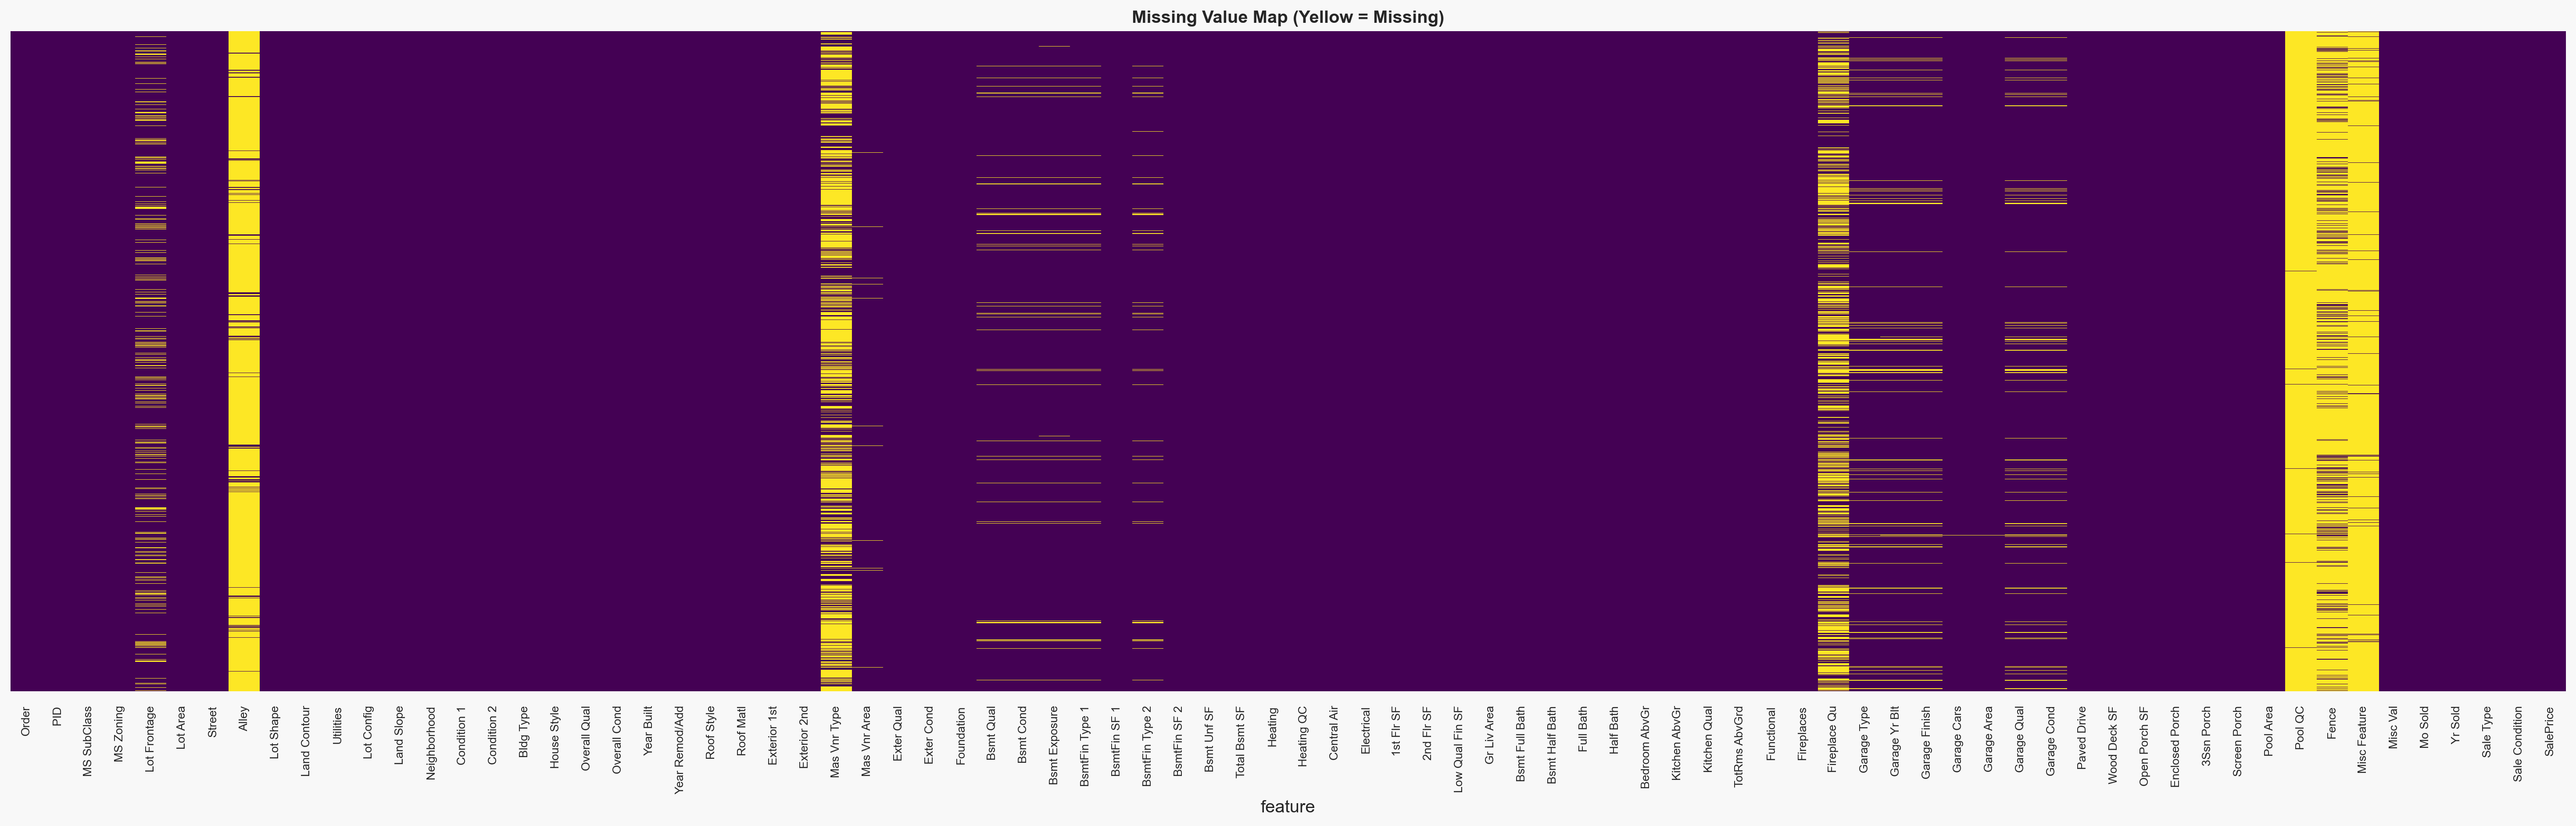

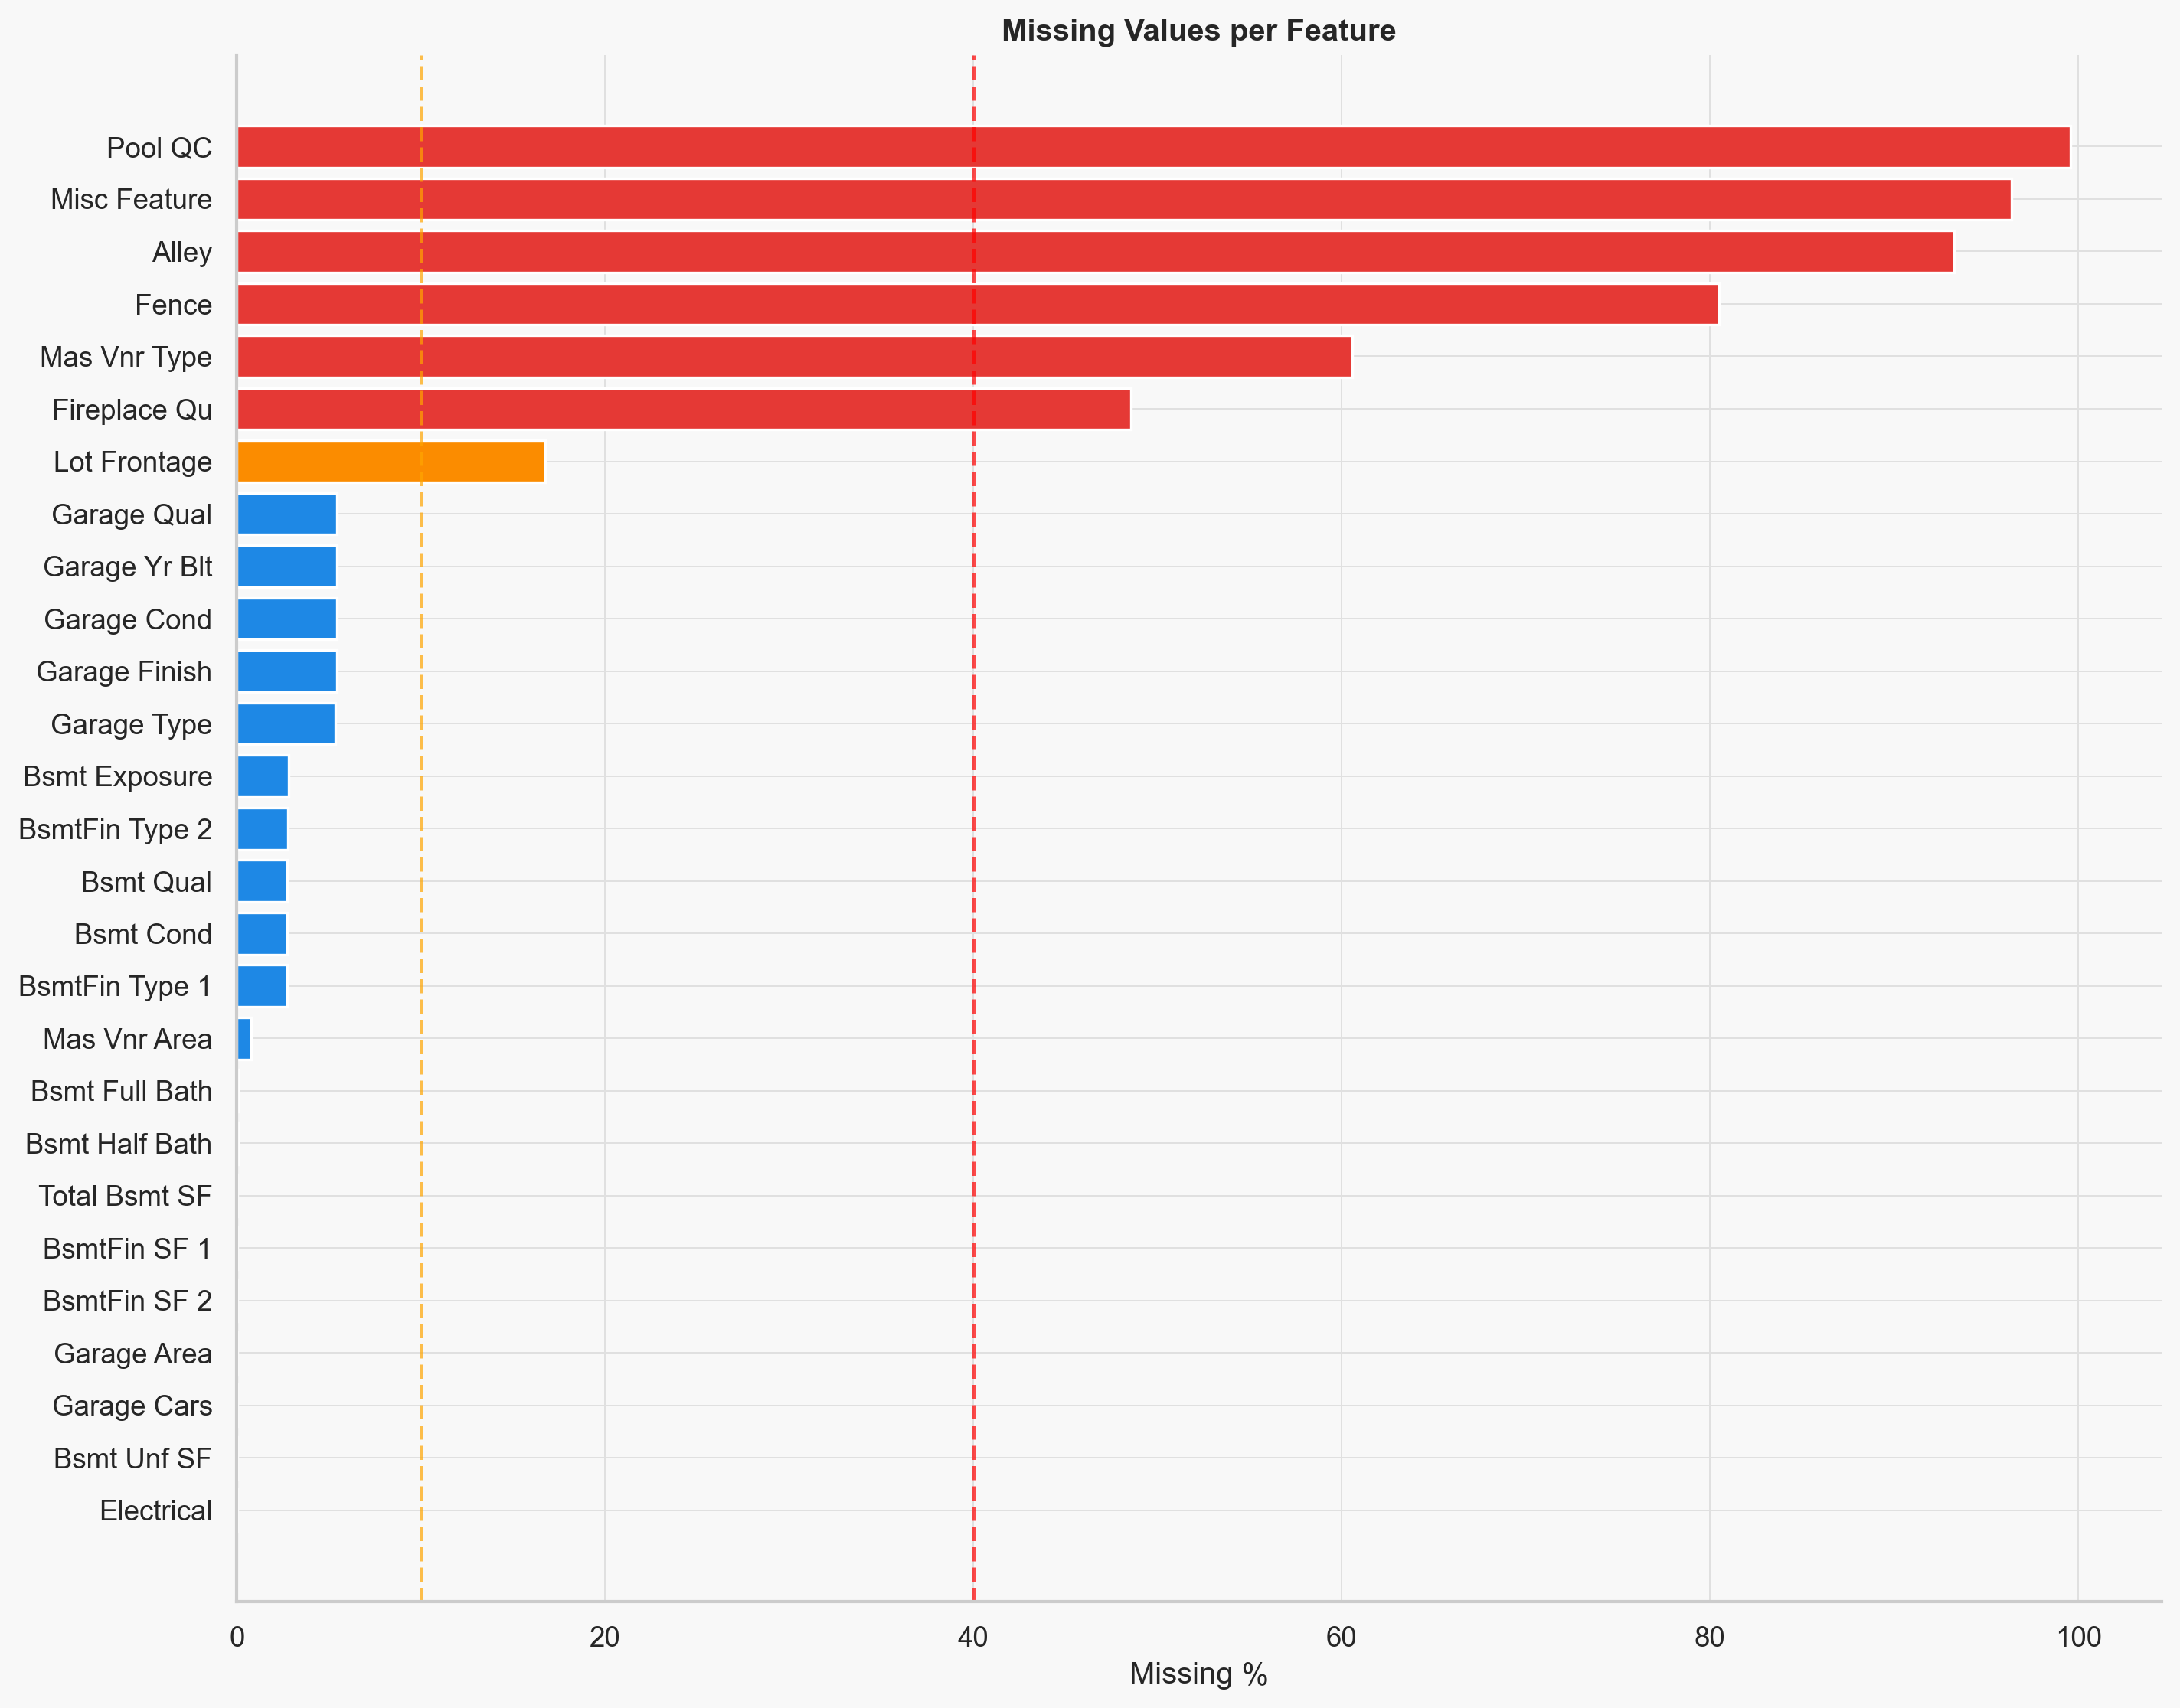

In [46]:
null_heatmap(df)
null_bar(df)